In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


From the dataset, it appears there are 9 features:

Pregnancies,	Glucose, BloodPressure,	SkinThickness,	Insulin,	BMI
DiabetesPedigreeFunction,	Age,	Outcome

Outcome
0    500
1    268
Name: count, dtype: int64


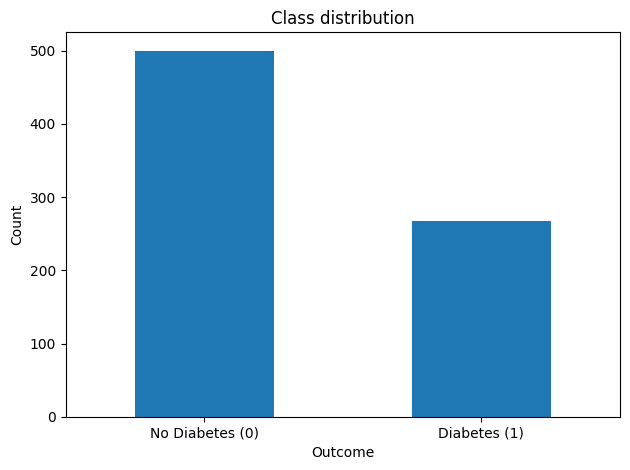

In [57]:
class_counts = df["Outcome"].value_counts()
plt.figure()
class_counts.plot(kind='bar')
plt.title("Class distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
print(class_counts)
plt.xticks([0,1], ["No Diabetes (0)", "Diabetes (1)"], rotation=0)
plt.tight_layout()
plt.show()

It appears there is class imbalance within the dataset

In [39]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


We can see that none of the rows contain null values. As such, missing values must use another representation, possibly zero.

In [40]:
(df==0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


The only rows that can realistically contain zero are Pregnancie sand DiabetesPedigreeFunction. So to begin we will treat 0 as a mising value on all other rows.

In [41]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
(df[cols] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [42]:
cols_with_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)
(df==0).sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [43]:
df.isna().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


We have now replaced all zero values that need replacing with Null values

In [44]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Train Test Split


I am going to do the train test split at this stage, as i have marked the missing values, but not yet corrected them to prevent **data leakage** between the two sets, making the model look better than it actually is performance wise during evaluation.
In the real world, missing values may be present, so it is important to test against this.

As such, imputation and scaling will be performed inside the pipeline to avoid leakage into the test set.

In [45]:
from sklearn.model_selection import train_test_split

x = df.drop(columns = ["Outcome"]) #input data
y = df["Outcome"] #output data (whats being predicted)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", x_train.shape, "X_val:", x_test.shape)
print("\nClass balance (full):\n", y.value_counts(normalize=True))
print("\nClass balance (train):\n", y_train.value_counts(normalize=True))
print("\nClass balance (val):\n", y_test.value_counts(normalize=True))

X_train: (614, 8) X_val: (154, 8)

Class balance (full):
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Class balance (train):
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class balance (val):
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


I have added the stratify = y line to this split to ensure a fair split of diabetic and non diabetic patients accross both sets, to prevent an introduction of bias.

# Pipeline creation


I will use the pipeline feature from sklearn to sequentially apply data cleaning, scaling and then training in the model, to avoid issues such as overfitting, or missing steps which can happen when doing this stage manually.

I used the balanced parameter to handle classs imbalance, which isthe case in this dataset, this may lead to more false positives, but has the trade off in less probability of failing to flag true diabatics, which is better for a health screening tool, such that further tests can be administered to form a conclusive result.

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # replace previously outlined nan values.
    ("scaler", StandardScaler()), # scale for outliers
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))#increase iter from default of 100, in case not enough to converge
])

In [47]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

# Model Evaluation


The below cell evaluates the model performance. The accuracy is output along with a table detailing presicicon, recall and f1 scores for each class.


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = pipeline.predict(x_test) # return predicted class label (0 or 1 for diabetes)
y_prob = pipeline.predict_proba(x_test)[:,1] # return confidence in each class

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



Demonstrate confusion matrix, showing The true and false positives/negatives.

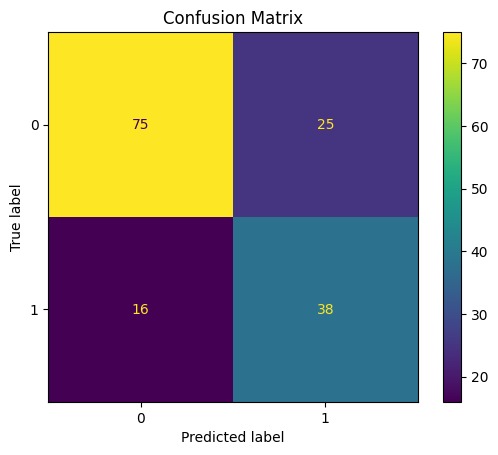

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

Recall score - How many diabetic patients did the model accuretly predict? A high score is important in this healthcare context.


In [50]:
from sklearn.metrics import recall_score

Recall = recall_score(y_test, y_pred)
print(Recall)

0.7037037037037037


The Auc-Roc score calculates the predicted probabilites for the positive class, comparing them to the False and True Positive rates (FPR, TPR), The score reflects the models descimitaive ability.

In [51]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_roc = auc(fpr, tpr)

print(auc_roc)

0.8125925925925926


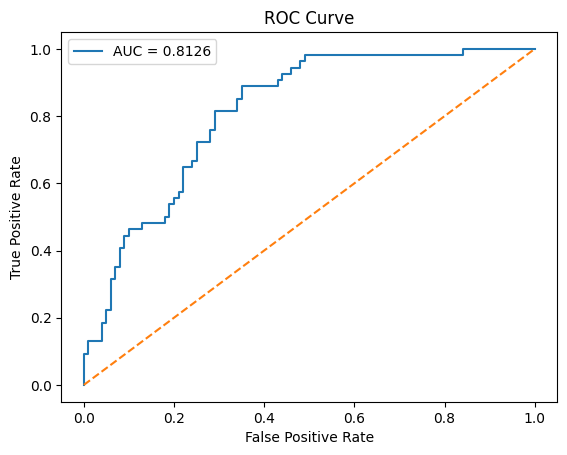

In [52]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

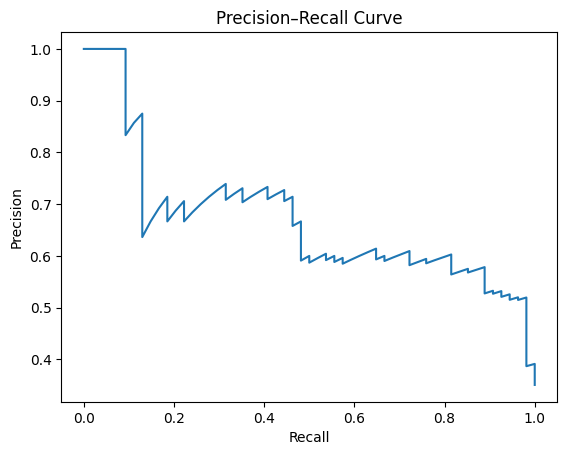

In [53]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

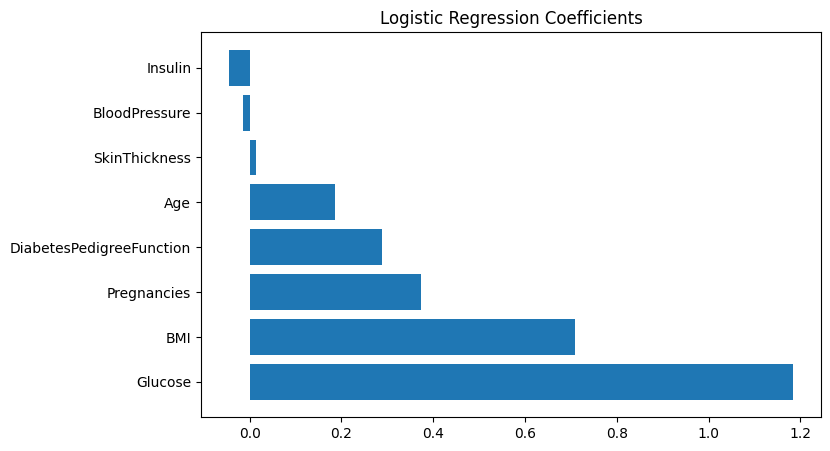

In [54]:
coefficients = pipeline.named_steps["model"].coef_[0]
features = x.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df

plt.figure(figsize=(8,5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Logistic Regression Coefficients")
plt.show()